# Motion-Phase ML: End-to-End Workflow

## Notebook Guide
- **Part 1: Dataset Overview:** quick health checks, class balance, and sensor visualizations.
- **Part 2: Preprocessing:** duplicate removal, timestamp cleanup, sampling-rate diagnostics, and segmentation.
- **Part 3: Feature Engineering:** engineered statistics and spectral features, feature ranking, and artifact generation for modeling.

## Setup and Configuration

This section imports all required libraries and defines global settings used throughout the notebook. It covers:
- Data handling and plotting libraries for analysis and diagnostics.
- Signal processing and feature-selection tools .
- Reproducible output paths and constants.

In [234]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.fft import rfft, rfftfreq
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

plt.style.use("seaborn-v0_8")
sns.set_palette("crest")

In [235]:

DATA_PATH = Path("biosensor_dataset_with_target.csv")
print(f"Using dataset at: {DATA_PATH.resolve()}")

Using dataset at: /Users/swornimbasnet/Projects/CS156---Project-Motion-Phase-ML/biosensor_dataset_with_target.csv


In [236]:
df_raw = pd.read_csv(DATA_PATH)
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"], errors="coerce")

print(f"Rows: {len(df_raw):,}  |  Columns: {len(df_raw.columns)}")
print(df_raw.info())


Rows: 1,500  |  Columns: 10
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Heart_Rate   1500 non-null   int64         
 1   Acc_X        1500 non-null   float64       
 2   Acc_Y        1500 non-null   float64       
 3   Acc_Z        1500 non-null   float64       
 4   Gyro_X       1500 non-null   float64       
 5   Gyro_Y       1500 non-null   float64       
 6   Gyro_Z       1500 non-null   float64       
 7   Event_Label  1500 non-null   str           
 8   Timestamp    1500 non-null   datetime64[us]
 9   Athlete_ID   1500 non-null   str           
dtypes: datetime64[us](1), float64(6), int64(1), str(2)
memory usage: 117.3 KB
None


### Runtime Parameters and Output Paths

In [237]:
OUT_DIR = Path("out")
FEATURE_OUT_DIR = OUT_DIR / "feature_engineering"
PLOT_DIR = FEATURE_OUT_DIR / "plots"

WINDOW_SECONDS = 0.5
STEP_RATIO = 0.5
STEP_SECONDS = WINDOW_SECONDS * STEP_RATIO
TOP_K = 15

LABEL_SMOOTH_WINDOW = 3
MIN_LABEL_PURITY = 0.5
USE_PURITY_FILTER_FOR_FEATURES = True
MIN_FEATURE_SAMPLES = 4

SANITY_THRESHOLDS = {
    "Heart_Rate": (60.0, 190.0),
    "Acc_X": (-3.2, 3.2),
    "Acc_Y": (-3.2, 3.2),
    "Acc_Z": (-3.2, 3.2),
    "Gyro_X": (-190.0, 190.0),
    "Gyro_Y": (-190.0, 190.0),
    "Gyro_Z": (-190.0, 190.0),
}

RAW_SENSOR_COLS = [
    "Heart_Rate", "Acc_X", "Acc_Y", "Acc_Z",
    "Gyro_X", "Gyro_Y", "Gyro_Z"
]

FEATURE_FILE_TAG = (
    f"w{WINDOW_SECONDS:.2f}_step{STEP_RATIO:.2f}_purity{MIN_LABEL_PURITY:.2f}"
    .replace(".", "p")
)

OUT_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Artifacts will be saved under {OUT_DIR.resolve()}")

Artifacts will be saved under /Users/swornimbasnet/Projects/CS156---Project-Motion-Phase-ML/out


## PART 1: DATASET OVERVIEW PORTION

### Read Raw Data from File

This cell loads the biosensor CSV into a dataframe and converts `Timestamp` into a proper datetime column.

It gives a first check that:
- the file path is correct,
- the dataset has the expected columns,
- timestamps can be parsed successfully before any cleaning or feature work starts.

The printed summary and preview help confirm the raw file was read correctly.

In [238]:
df_raw = pd.read_csv(DATA_PATH)
df_raw["Timestamp"] = pd.to_datetime(df_raw["Timestamp"], errors="coerce")

print(f"Rows: {len(df_raw):,}  |  Columns: {len(df_raw.columns)}")
print(df_raw.info())


Rows: 1,500  |  Columns: 10
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Heart_Rate   1500 non-null   int64         
 1   Acc_X        1500 non-null   float64       
 2   Acc_Y        1500 non-null   float64       
 3   Acc_Z        1500 non-null   float64       
 4   Gyro_X       1500 non-null   float64       
 5   Gyro_Y       1500 non-null   float64       
 6   Gyro_Z       1500 non-null   float64       
 7   Event_Label  1500 non-null   str           
 8   Timestamp    1500 non-null   datetime64[us]
 9   Athlete_ID   1500 non-null   str           
dtypes: datetime64[us](1), float64(6), int64(1), str(2)
memory usage: 117.3 KB
None


### Compute Derived Magnitude Signals

Calculate the Euclidean magnitude of 3-axis accelerometer and gyroscope readings.
These provide a single measure of overall intensity without axis decomposition.


In [239]:
df_raw["Acc_Mag"] = np.sqrt(df_raw["Acc_X"]**2 + df_raw["Acc_Y"]**2 + df_raw["Acc_Z"]**2)
df_raw["Gyro_Mag"] = np.sqrt(df_raw["Gyro_X"]**2 + df_raw["Gyro_Y"]**2 + df_raw["Gyro_Z"]**2)
print("✓ Computed Acc_Mag and Gyro_Mag")

✓ Computed Acc_Mag and Gyro_Mag


### Class Balance Snapshot

Computes counts and percentages for each motion phase label, then visualizes class frequency.

,count,percent
Event_Label,,
Start_Run,281,18.73
Stop,257,17.13
Jump_Takeoff,246,16.40
Sprint_Mid,245,16.33
Accel,241,16.07
Landing,230,15.33


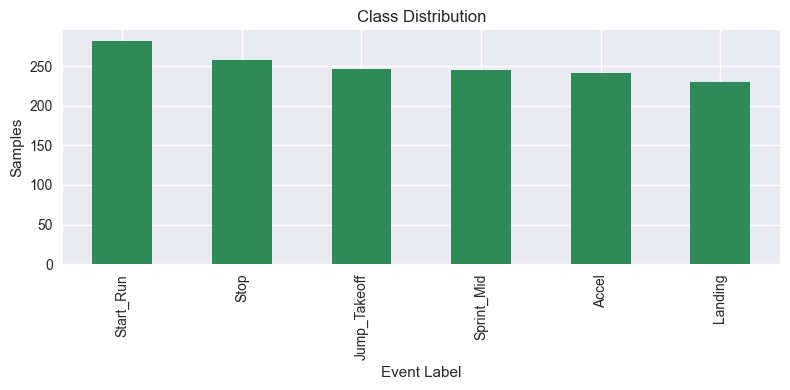

In [240]:
# class distribution
class_counts = df_raw['Event_Label'].value_counts()

display(pd.DataFrame({"count": class_counts, "percent": (class_counts / len(df_raw) * 100).round(2)}))
ax = class_counts.plot(kind="bar", color="seagreen", figsize=(8, 4))
ax.set(title="Class Distribution", xlabel="Event Label", ylabel="Samples")
plt.tight_layout()
plt.show()

### Missing-Value Audit

Summarizes missing values per column and reports total missing entries.

In [241]:
# check for missing vals

missing_counts = df_raw.isna().sum()
missing_summary = pd.DataFrame({
    "missing": missing_counts,
    "missing_pct": (missing_counts / len(df_raw) * 100).round(2)
}).sort_values("missing", ascending=False)

display(missing_summary)


,missing,missing_pct
Heart_Rate,0,0.0
Acc_X,0,0.0
Acc_Y,0,0.0
Acc_Z,0,0.0
Gyro_X,0,0.0
Gyro_Y,0,0.0
Gyro_Z,0,0.0
Event_Label,0,0.0
Timestamp,0,0.0
Athlete_ID,0,0.0


### Per-Class Summary Statistics

Tabular breakdown of sensor means and standard deviations grouped by motion phase.
Includes the new magnitude signals alongside raw axis values for direct comparison.


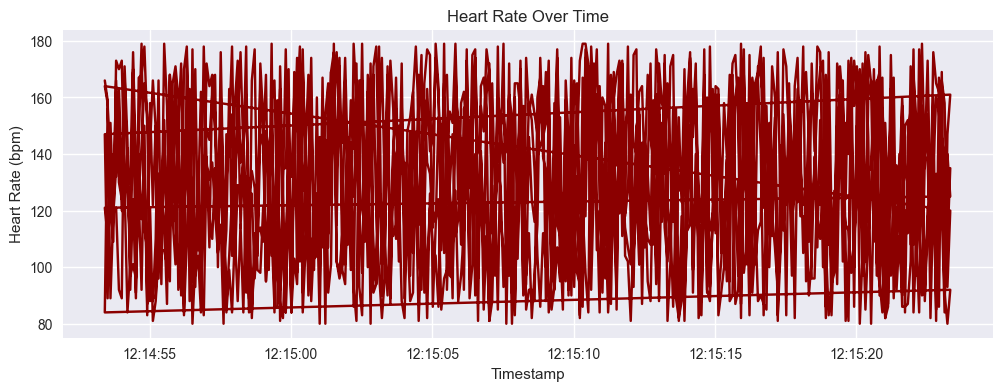

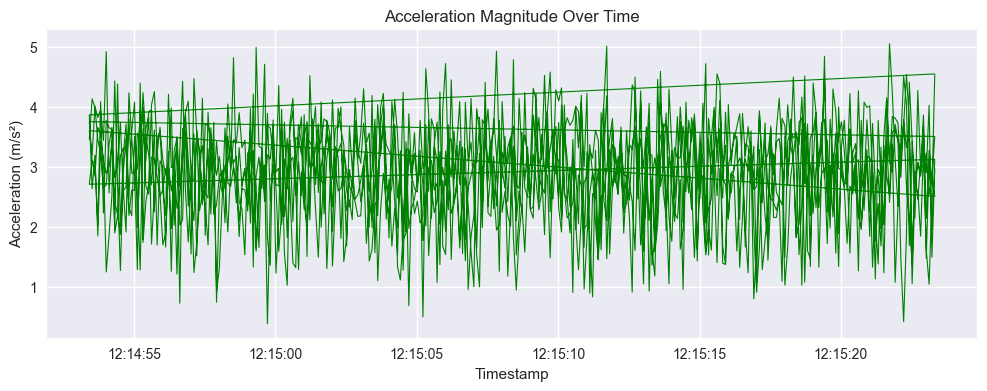

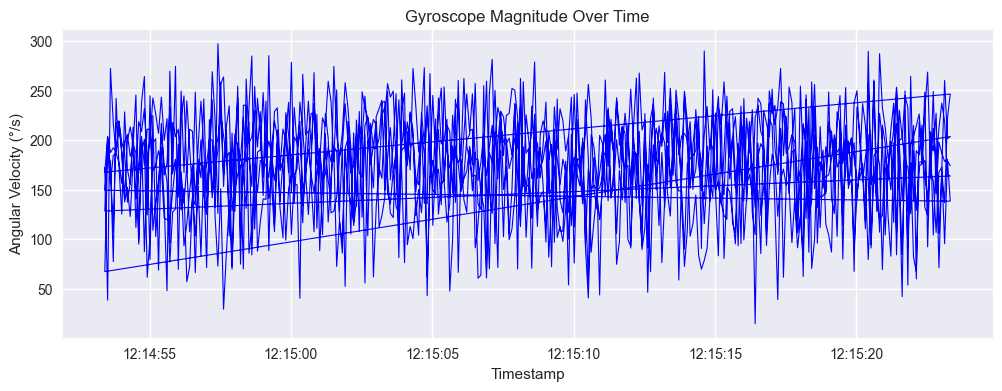

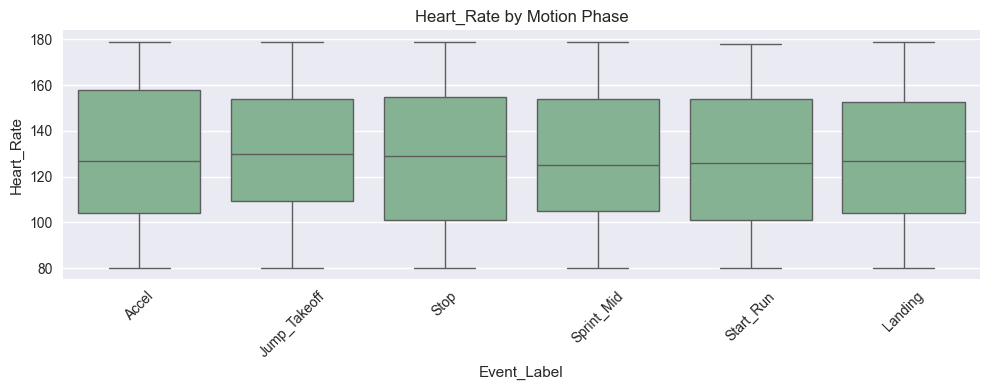

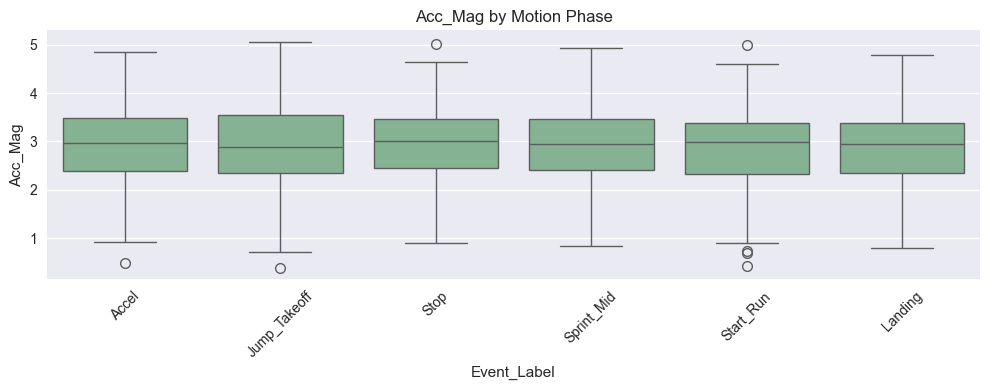

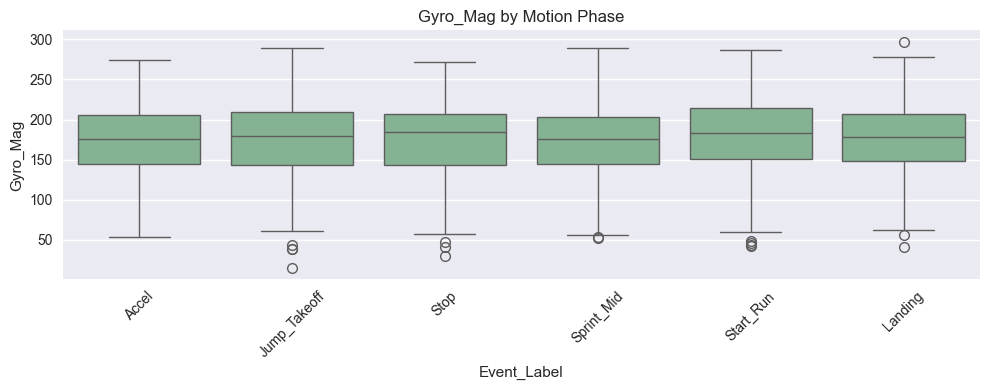

In [242]:
# heart rate over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Heart_Rate'], color='darkred')
plt.title('Heart Rate Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Heart Rate (bpm)')
plt.show()

# accelerometer magnitude over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Acc_Mag'], color='green', linewidth=0.8)
plt.title('Acceleration Magnitude Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Acceleration (m/s²)')
plt.show()

# gyroscope magnitude over time
plt.figure(figsize=(12, 4))
plt.plot(df_raw['Timestamp'], df_raw['Gyro_Mag'], color='blue', linewidth=0.8)
plt.title('Gyroscope Magnitude Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Angular Velocity (°/s)')
plt.show()

# sensor magnitudes by motion phase
for sensor in ['Heart_Rate', 'Acc_Mag', 'Gyro_Mag']:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x='Event_Label', y=sensor, data=df_raw)
    plt.title(f'{sensor} by Motion Phase')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [243]:
# Per-class summary statistics
all_sensor_cols = RAW_SENSOR_COLS + ["Acc_Mag", "Gyro_Mag"]
summary_stats = df_raw.groupby('Event_Label')[all_sensor_cols].agg(['mean', 'std']).round(2)
display(summary_stats)


Heart_Rate        Acc_X       Acc_Y       Acc_Z       Gyro_X  \
                   mean    std  mean   std  mean   std  mean   std   mean   
Event_Label                                                                 
Accel            129.05  30.12  0.06  1.75  0.01  1.74 -0.04  1.74  -9.78   
Jump_Takeoff     130.89  27.53 -0.09  1.74  0.07  1.77  0.02  1.70   6.93   
Landing          128.97  29.54 -0.26  1.71 -0.06  1.73  0.03  1.68   2.59   
Sprint_Mid       128.84  28.28  0.06  1.73  0.17  1.76  0.23  1.70  -5.71   
Start_Run        127.38  29.50 -0.02  1.77 -0.11  1.69  0.09  1.68  -6.00   
Stop             128.74  29.79 -0.16  1.84  0.10  1.77  0.28  1.63   1.97   

                     Gyro_Y         Gyro_Z         Acc_Mag       Gyro_Mag  \
                 std   mean     std   mean     std    mean   std     mean   
Event_Label                                                                 
Accel          98.73   6.53  103.24   7.06  107.11    2.91  0.81   172.91   
Jump_Takeoff  107.99   9.83  104.24  -1.26  102.32    2.88  0.87   174.73   
Landing       104.40   3.89  109.47  12.77  100.93    2.85  0.81   175.40   
Sprint_Mid    103.91 -11.71  104.63  -0.24  100.88    2.90  0.81   172.19   
Start_Run     106.49   8.22  107.90   4.57  107.38    2.86  0.78   178.58   
Stop          107.45   9.07  104.25   3.77  101.88    2.94  0.79   174.16   

                     
                std  
Event_Label          
Accel         45.24  
Jump_Takeoff  49.90  
Landing       48.55  
Sprint_Mid    48.18  
Start_Run     51.31  
Stop          49.43

## PART 2: DATASET PREPROCESSING

### Clean Records and Normalize Labels
- Removes duplicate rows.
- Drops invalid timestamps.
- Sorts by athlete and time.
- Normalizes `Event_Label` text for consistent grouping and modeling.

In [244]:
df_clean = df_raw.copy()

rows_before = len(df_clean)
df_clean = df_clean.drop_duplicates(keep="first").reset_index(drop=True)
print(f"Removed {rows_before - len(df_clean)} duplicate rows")

invalid_ts = int(df_clean["Timestamp"].isna().sum())
if invalid_ts:
    print(f"Dropping {invalid_ts} rows with invalid timestamps")
    df_clean = df_clean.dropna(subset=["Timestamp"]).reset_index(drop=True)

df_clean = df_clean.sort_values(["Athlete_ID", "Timestamp"]).reset_index(drop=True)
df_clean["Event_Label"] = df_clean["Event_Label"].astype(str).str.strip().str.lower()


Removed 0 duplicate rows


### Label Smoothing for Training Windows

Apply per-athlete majority smoothing on motion labels to reduce rapid flips before segmentation.
This improves window purity while preserving overall phase structure.


In [245]:
def smooth_majority_labels(labels, window):
    labels = np.asarray(labels, dtype=object)
    n = len(labels)
    out = labels.copy()
    half = window // 2

    for i in range(n):
        lo = max(0, i - half)
        hi = min(n, i + half + 1)
        vals = labels[lo:hi]
        unique_vals, counts = np.unique(vals, return_counts=True)

        max_count = counts.max()
        candidates = unique_vals[counts == max_count]
        center_label = labels[i]

        if center_label in candidates:
            out[i] = center_label
        elif i > 0 and out[i - 1] in candidates:
            out[i] = out[i - 1]
        else:
            out[i] = candidates[0]

    return out


df_clean["Event_Label_Original"] = df_clean["Event_Label"]
smoothed_parts = []
for _, athlete_df in df_clean.groupby("Athlete_ID", sort=False):
    smoothed_parts.append(
        pd.Series(
            smooth_majority_labels(athlete_df["Event_Label"].to_numpy(), LABEL_SMOOTH_WINDOW),
            index=athlete_df.index,
        )
    )

df_clean["Event_Label"] = pd.concat(smoothed_parts).sort_index()
changed_pct = (df_clean["Event_Label"] != df_clean["Event_Label_Original"]).mean() * 100
print(f"Applied label smoothing (window={LABEL_SMOOTH_WINDOW}). Changed {changed_pct:.2f}% of rows.")


Applied label smoothing (window=3). Changed 14.07% of rows.


### Model-Readiness Diagnostics

These checks validate whether the cleaned dataset is suitable for supervised classification and help prevent common failure modes:
- Label-noise signals from rapid phase flips.
- Athlete-wise imbalance that can bias models.
- Subject-wise split sanity to avoid leakage.
- Missing/out-of-range patterns by class.
- Low-dimensional separability using key magnitude features.


In [246]:
# 1) Label quality check via consecutive run lengths
label_runs = df_clean.sort_values(["Athlete_ID", "Timestamp"])[["Athlete_ID", "Timestamp", "Event_Label"]].copy()
label_change = label_runs["Event_Label"].ne(label_runs.groupby("Athlete_ID")["Event_Label"].shift())
label_runs["run_id"] = label_change.groupby(label_runs["Athlete_ID"]).cumsum()

run_stats = (
    label_runs
    .groupby(["Athlete_ID", "run_id", "Event_Label"], as_index=False)
    .agg(
        n_samples=("Event_Label", "size"),
        start_time=("Timestamp", "min"),
        end_time=("Timestamp", "max"),
    )
)
run_stats["duration_s"] = (run_stats["end_time"] - run_stats["start_time"]).dt.total_seconds().fillna(0.0)

SHORT_RUN_SAMPLES = 5
short_run_summary = (
    run_stats.assign(short_run=run_stats["n_samples"] < SHORT_RUN_SAMPLES)
    .groupby("Event_Label", as_index=False)["short_run"]
    .mean()
)
short_run_summary["short_run_pct"] = (short_run_summary["short_run"] * 100).round(2)

display(run_stats[["n_samples", "duration_s"]].describe().round(2))
display(short_run_summary[["Event_Label", "short_run_pct"]].sort_values("short_run_pct", ascending=False))


,n_samples,duration_s
count,897.00,897.00
mean,1.67,0.07
std,1.16,0.12
min,1.00,0.00
25%,1.00,0.00
50%,1.00,0.00
75%,2.00,0.10
max,8.00,0.70


,Event_Label,short_run_pct
3,sprint_mid,97.96
4,start_run,97.62
2,landing,96.71
1,jump_takeoff,95.21
5,stop,94.52
0,accel,93.48


Event_Label,accel,jump_takeoff,landing,sprint_mid,start_run,stop
Athlete_ID,,,,,,
A001,17.33,16.67,18.00,15.33,15.67,17.00
A002,14.67,15.33,11.33,15.33,18.67,24.67
A003,17.00,16.00,15.00,15.00,20.00,17.00
A004,15.33,14.67,16.33,16.00,18.33,19.33
A005,17.00,18.33,15.67,14.33,21.00,13.67


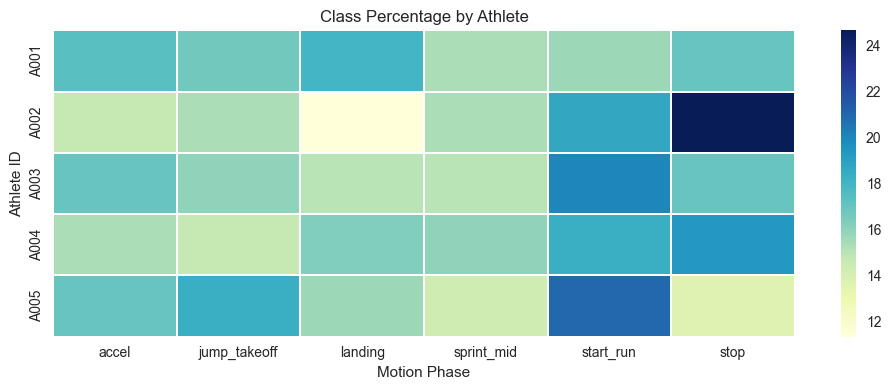

In [247]:
# 2) Per-athlete class balance (row-normalized)
athlete_phase_pct = (pd.crosstab(df_clean["Athlete_ID"], df_clean["Event_Label"], normalize="index") * 100).round(2)
display(athlete_phase_pct)

plt.figure(figsize=(10, max(4, 0.35 * athlete_phase_pct.shape[0])))
sns.heatmap(athlete_phase_pct, cmap="YlGnBu", linewidths=0.2)
plt.title("Class Percentage by Athlete")
plt.xlabel("Motion Phase")
plt.ylabel("Athlete ID")
plt.tight_layout()
plt.show()


In [248]:
# 3) Subject-wise split check (athlete-level split)
athletes = np.array(sorted(df_clean["Athlete_ID"].dropna().unique()))
rng = np.random.default_rng(42)
shuffled_athletes = athletes.copy()
rng.shuffle(shuffled_athletes)

n_train = max(1, int(round(0.8 * len(shuffled_athletes))))
train_athletes = set(shuffled_athletes[:n_train])
test_athletes = set(shuffled_athletes[n_train:])

overlap = train_athletes.intersection(test_athletes)
print(f"Train athletes: {len(train_athletes)} | Test athletes: {len(test_athletes)}")
print(f"Athlete overlap between splits: {len(overlap)}")
print("No leakage from athlete overlap." if len(overlap) == 0 else "Potential leakage detected.")


Train athletes: 4 | Test athletes: 1
Athlete overlap between splits: 0
No leakage from athlete overlap.


In [249]:
# 4) Missingness and out-of-range rates by motion phase
check_cols = RAW_SENSOR_COLS + ["Acc_Mag", "Gyro_Mag"]

missing_pct_by_class = (
    df_clean.groupby("Event_Label")[check_cols]
    .apply(lambda d: d.isna().mean() * 100)
    .round(2)
)

outlier_rows = []
for label, group in df_clean.groupby("Event_Label"):
    row = {"Event_Label": label}
    for col, (low, high) in SANITY_THRESHOLDS.items():
        if col in group.columns:
            row[f"{col}_out_of_range_pct"] = round((((group[col] < low) | (group[col] > high)).mean() * 100), 2)
    outlier_rows.append(row)

outlier_pct_by_class = pd.DataFrame(outlier_rows).set_index("Event_Label")

print("Missing percentage by class")
display(missing_pct_by_class)
print("Out-of-range percentage by class")
display(outlier_pct_by_class)


Missing percentage by class


,Heart_Rate,Acc_X,Acc_Y,Acc_Z,Gyro_X,Gyro_Y,Gyro_Z,Acc_Mag,Gyro_Mag
Event_Label,,,,,,,,,
accel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
jump_takeoff,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
landing,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sprint_mid,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
start_run,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
stop,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Out-of-range percentage by class


,Heart_Rate_out_of_range_pct,Acc_X_out_of_range_pct,Acc_Y_out_of_range_pct,Acc_Z_out_of_range_pct,Gyro_X_out_of_range_pct,Gyro_Y_out_of_range_pct,Gyro_Z_out_of_range_pct
Event_Label,,,,,,,
accel,0.0,0.0,0.0,0.0,0.0,0.0,0.0
jump_takeoff,0.0,0.0,0.0,0.0,0.0,0.0,0.0
landing,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sprint_mid,0.0,0.0,0.0,0.0,0.0,0.0,0.0
start_run,0.0,0.0,0.0,0.0,0.0,0.0,0.0
stop,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Sampling-Rate Diagnostics

Estimates effective sampling frequency from timestamp differences. It reports median and mean intervals, interval variability, and ignored non-positive gaps to highlight timing irregularities.


In [250]:
sampling_rate_hz = np.nan

dt = df_clean.groupby("Athlete_ID")["Timestamp"].diff().dt.total_seconds().dropna()
non_positive = int((dt <= 0).sum())
dt = dt[dt > 0]

if dt.empty:
    print("Sampling-rate check: insufficient timestamp gaps.")
else:
    median_dt = float(dt.median())
    mean_dt = float(dt.mean())
    std_dt = float(dt.std()) if len(dt) > 1 else 0.0
    sampling_rate_hz = 1.0 / median_dt
    print(f"Median interval: {median_dt:.3f}s ({sampling_rate_hz:.2f} Hz)")
    print(f"Mean interval:   {mean_dt:.3f}s ({1.0/mean_dt:.2f} Hz)")
    print(f"Interval std:    {std_dt:.3f}s")
    if non_positive:
        print(f"Ignored {non_positive} non-positive gaps")
    display(dt.round(3).value_counts().head(5).to_frame(name="count"))

Median interval: 0.100s (10.00 Hz)
Mean interval:   0.100s (10.00 Hz)
Interval std:    0.000s


,count
Timestamp,
0.1,1495


### Sensor Range Checks

Compares observed numeric ranges with expected physiological and sensor limits.

In [251]:
numeric_cols = df_clean.select_dtypes(include="number").columns
range_rows = []
for col in numeric_cols:
    range_rows.append({
        "column": col,
        "min": float(df_clean[col].min()),
        "max": float(df_clean[col].max()),
    })
range_df = pd.DataFrame(range_rows).set_index("column")

display(range_df)

threshold_counts = {}
for col, (low, high) in SANITY_THRESHOLDS.items():
    if col in df_clean.columns:
        count = int(((df_clean[col] < low) | (df_clean[col] > high)).sum())
        threshold_counts[col] = count

display(pd.Series(threshold_counts, name="out_of_range"))

,min,max
column,,
Heart_Rate,80.000000,179.000000
Acc_X,-2.998485,2.999229
Acc_Y,-2.992459,2.999549
Acc_Z,-2.997461,2.997938
Gyro_X,-179.936814,179.890139
Gyro_Y,-179.996653,179.802188
Gyro_Z,-179.888497,179.877572
Acc_Mag,0.386245,5.059652
Gyro_Mag,14.690309,297.104021


Heart_Rate    0
Acc_X         0
Acc_Y         0
Acc_Z         0
Gyro_X        0
Gyro_Y        0
Gyro_Z        0
Name: out_of_range, dtype: int64

### Window Segmentation

Defines and applies a sliding-window segmentation function. For each athlete, it creates overlapping windows and computes quick summary statistics plus label purity, then saves the segmented output for reuse.

In [252]:
def segment_windows(data, window_seconds, step_seconds):
    sensor_cols = [col for col in SANITY_THRESHOLDS if col in data.columns]
    if not sensor_cols:
        return pd.DataFrame()

    window = pd.to_timedelta(window_seconds, unit="s")
    step = pd.to_timedelta(step_seconds, unit="s")
    segments = []

    for athlete_id, athlete_df in data.groupby("Athlete_ID", sort=False):
        athlete_df = athlete_df.sort_values("Timestamp")
        if athlete_df.empty:
            continue

        start = athlete_df["Timestamp"].min()
        end = athlete_df["Timestamp"].max()
        current = start

        while current + window <= end:
            window_end = current + window
            mask = (athlete_df["Timestamp"] >= current) & (athlete_df["Timestamp"] < window_end)
            win_df = athlete_df.loc[mask]

            if not win_df.empty:
                row = {
                    "Athlete_ID": athlete_id,
                    "window_start": current,
                    "window_end": window_end,
                    "n_samples": int(len(win_df)),
                }

                label_counts = win_df["Event_Label"].value_counts()
                row["Event_Label"] = label_counts.index[0]
                row["label_purity"] = float(label_counts.iloc[0] / len(win_df))

                for col in sensor_cols:
                    row[f"{col}_mean"] = float(win_df[col].mean())
                    row[f"{col}_std"] = float(win_df[col].std(ddof=0))

                segments.append(row)

            current += step

    return pd.DataFrame(segments)


segmented_windows_df = segment_windows(df_clean, WINDOW_SECONDS, STEP_SECONDS)
if segmented_windows_df.empty:
    print("Segmentation produced no windows.")
else:
    segmented_path = OUT_DIR / "segmented_windows.csv"
    segmented_windows_df.to_csv(segmented_path, index=False)

    filtered_windows_df = segmented_windows_df[segmented_windows_df["label_purity"] >= MIN_LABEL_PURITY].copy()
    filtered_segmented_path = OUT_DIR / f"segmented_windows_purity_ge_{str(MIN_LABEL_PURITY).replace('.', 'p')}.csv"
    filtered_windows_df.to_csv(filtered_segmented_path, index=False)

    print(f"Generated {len(segmented_windows_df):,} total windows -> {segmented_path}")
    print(f"Kept {len(filtered_windows_df):,} windows with purity >= {MIN_LABEL_PURITY:.2f} -> {filtered_segmented_path}")
    segmented_windows_df.head()


Generated 590 total windows -> out/segmented_windows.csv
Kept 294 windows with purity >= 0.50 -> out/segmented_windows_purity_ge_0p5.csv


### Window Purity Distribution (Post-Segmentation)

Checks the label purity of each window. Low-purity windows often hurt supervised training and can be filtered before modeling.


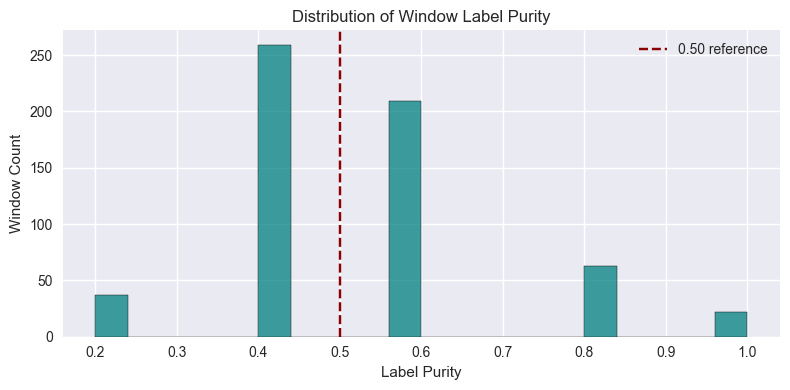

Windows with purity >= 0.50: 49.83%


In [253]:
if segmented_windows_df.empty:
    print("No windows available for purity diagnostics.")
else:
    plt.figure(figsize=(8, 4))
    sns.histplot(segmented_windows_df["label_purity"], bins=20, color="teal")
    plt.axvline(MIN_LABEL_PURITY, color="darkred", linestyle="--", label=f"{MIN_LABEL_PURITY:.2f} reference")
    plt.title("Distribution of Window Label Purity")
    plt.xlabel("Label Purity")
    plt.ylabel("Window Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    purity_share = (
        (segmented_windows_df["label_purity"] >= MIN_LABEL_PURITY)
        .mean() * 100
    )
    print(f"Windows with purity >= {MIN_LABEL_PURITY:.2f}: {purity_share:.2f}%")


# FEATURE ENGINEERING
- Define reusable helper functions for temporal and spectral descriptors.
- Extract per-window features from cleaned and smoothed data.
- Keep only model-ready windows using purity and minimum-sample guards.
- Rank features using train-athlete data to reduce leakage risk.
- Export selected features and diagnostics to support downstream model training.



In [254]:
df_features_input = df_clean.copy()

### Helper Functions for Feature Computation

These utility functions compute robust signal descriptors:
- Zero-crossing rate (time-domain variability).
- Frequency-domain metrics (dominant frequency, spectral energy, entropy).
- Safe correlation with guards for short or constant signals.

In [255]:
def zero_crossing_rate(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return 0.0


    centered = x - np.mean(x)
    signs = np.sign(centered)

    for i in range(1, len(signs)):
        if signs[i] == 0:
            signs[i] = signs[i - 1]


    if signs[0] == 0:
        signs[0] = 1

    crossings = np.sum(signs[:-1] * signs[1:] < 0)
    return float(crossings / (len(x) - 1))


def spectral_features(x, sampling_rate_hz):
    x = np.asarray(x, dtype=float)
    n = len(x)

    if n < 2:
        return 0.0, 0.0, 0.0


    centered = x - np.mean(x)
    power = np.abs(rfft(centered)) ** 2
    freqs = rfftfreq(n, d=1.0 / sampling_rate_hz)

    if len(power) <= 1:
        dominant_freq = 0.0
    else:
        dominant_index = int(np.argmax(power[1:])) + 1
        dominant_freq = float(freqs[dominant_index])

    spectral_energy = float(np.sum(power) / n)


    power_sum = np.sum(power)
    if power_sum <= 0 or len(power) <= 1:
        spectral_entropy = 0.0
    else:
        prob = power / power_sum
        spectral_entropy = float(-np.sum(prob * np.log2(prob + 1e-12)) / np.log2(len(prob)))

    return dominant_freq, spectral_energy, spectral_entropy


def safe_corr(a, b):

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)


    if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0:
        return 0.0

    return float(np.corrcoef(a, b)[0, 1])

### Window-Level Feature Extraction

Slides across each athlete's timeline and computes feature vectors per window. Each row includes:
- Label and purity metadata.
- Time-domain and spectral statistics for all sensor channels.
- Cross-axis correlation features for accelerometer and gyroscope signals.

The resulting table is saved for feature selection and model training.

In [256]:

def extract_window_features(df, sampling_rate_hz, window_seconds=1.0, step_ratio=0.5, min_samples=1):
    signal_cols = RAW_SENSOR_COLS + ["Acc_Mag", "Gyro_Mag"]
    window_delta = pd.to_timedelta(window_seconds, unit="s")
    step_seconds = max(window_seconds * step_ratio, 0.1)
    step_delta = pd.to_timedelta(step_seconds, unit="s")

    rows = []

    for athlete_id, athlete_df in df.groupby("Athlete_ID", sort=False):
        athlete_df = athlete_df.sort_values("Timestamp")
        start_time = athlete_df["Timestamp"].min()
        end_time = athlete_df["Timestamp"].max()
        current_time = start_time

        while current_time + window_delta <= end_time:
            window_end = current_time + window_delta
            win_df = athlete_df[(athlete_df["Timestamp"] >= current_time) & (athlete_df["Timestamp"] < window_end)]

            if len(win_df) >= min_samples:
                label_counts = win_df["Event_Label"].value_counts()
                row = {
                    "Athlete_ID": athlete_id,
                    "window_start": current_time,
                    "window_end": window_end,
                    "window_seconds": window_seconds,
                    "step_seconds": step_seconds,
                    "n_samples": int(len(win_df)),
                    "Event_Label": label_counts.index[0],
                    "label_purity": float(label_counts.iloc[0] / len(win_df)),
                }

                for col in signal_cols:
                    x = win_df[col].to_numpy(dtype=float)
                    row[f"{col}_mean"] = float(np.mean(x))
                    row[f"{col}_std"] = float(np.std(x, ddof=0))
                    row[f"{col}_rms"] = float(np.sqrt(np.mean(np.square(x))))
                    row[f"{col}_zcr"] = zero_crossing_rate(x)
                    dom_freq, spec_energy, spec_entropy = spectral_features(x, sampling_rate_hz)
                    row[f"{col}_dom_freq"] = dom_freq
                    row[f"{col}_spec_energy"] = spec_energy
                    row[f"{col}_spec_entropy"] = spec_entropy

                row["Acc_XY_corr"] = safe_corr(win_df["Acc_X"], win_df["Acc_Y"])
                row["Acc_XZ_corr"] = safe_corr(win_df["Acc_X"], win_df["Acc_Z"])
                row["Acc_YZ_corr"] = safe_corr(win_df["Acc_Y"], win_df["Acc_Z"])
                row["Gyro_XY_corr"] = safe_corr(win_df["Gyro_X"], win_df["Gyro_Y"])
                row["Gyro_XZ_corr"] = safe_corr(win_df["Gyro_X"], win_df["Gyro_Z"])
                row["Gyro_YZ_corr"] = safe_corr(win_df["Gyro_Y"], win_df["Gyro_Z"])

                rows.append(row)

            current_time += step_delta

    return pd.DataFrame(rows)


feature_df_all = extract_window_features(
    df=df_features_input,
    sampling_rate_hz=sampling_rate_hz,
    window_seconds=WINDOW_SECONDS,
    step_ratio=STEP_RATIO,
    min_samples=MIN_FEATURE_SAMPLES,
)

feature_all_path = FEATURE_OUT_DIR / f"engineered_features_all_{FEATURE_FILE_TAG}.csv"
feature_df_all.to_csv(feature_all_path, index=False)

if USE_PURITY_FILTER_FOR_FEATURES:
    feature_df = feature_df_all[feature_df_all["label_purity"] >= MIN_LABEL_PURITY].copy()
else:
    feature_df = feature_df_all.copy()

feature_model_path = FEATURE_OUT_DIR / f"engineered_features_model_{FEATURE_FILE_TAG}.csv"
feature_df.to_csv(feature_model_path, index=False)

print(f"All extracted features: {feature_df_all.shape} -> {feature_all_path}")
print(f"Modeling feature set:  {feature_df.shape} -> {feature_model_path}")
feature_df.head()


All extracted features: (590, 77) -> out/feature_engineering/engineered_features_all_w0p50_step0p50_purity0p50.csv
Modeling feature set:  (294, 77) -> out/feature_engineering/engineered_features_model_w0p50_step0p50_purity0p50.csv


,Athlete_ID,window_start,window_end,window_seconds,step_seconds,n_samples,Event_Label,label_purity,Heart_Rate_mean,Heart_Rate_std,...,Gyro_Mag_zcr,Gyro_Mag_dom_freq,Gyro_Mag_spec_energy,Gyro_Mag_spec_entropy,Acc_XY_corr,Acc_XZ_corr,Acc_YZ_corr,Gyro_XY_corr,Gyro_XZ_corr,Gyro_YZ_corr
5,A001,2025-05-11 12:14:54.667747,2025-05-11 12:14:55.167747,0.5,0.25,5,accel,1.0,161.0,12.712199,...,0.50,2.0,7732.213656,0.613071,-0.008651,0.240630,-0.639975,0.072085,-0.670267,-0.300569
6,A001,2025-05-11 12:14:54.917747,2025-05-11 12:14:55.417747,0.5,0.25,5,accel,0.6,140.8,23.659248,...,0.75,4.0,7008.707319,0.022882,0.533063,-0.263994,-0.458794,0.070723,0.022390,-0.969342
11,A001,2025-05-11 12:14:56.167747,2025-05-11 12:14:56.667747,0.5,0.25,5,start_run,0.6,141.4,29.910533,...,0.50,2.0,5168.961904,0.185804,-0.420537,-0.921760,0.105348,0.062841,-0.365062,-0.562349
12,A001,2025-05-11 12:14:56.417747,2025-05-11 12:14:56.917747,0.5,0.25,5,stop,0.6,109.4,19.438107,...,0.75,4.0,3716.157027,0.472123,-0.028898,-0.975692,-0.109336,-0.644580,0.378573,-0.779339
14,A001,2025-05-11 12:14:56.917747,2025-05-11 12:14:57.417747,0.5,0.25,5,landing,0.6,127.2,11.124747,...,1.00,4.0,5955.671469,0.411388,-0.899973,-0.332606,-0.075821,-0.556863,0.671775,-0.734145


### Feature Ranking and Selection

This stage ranks engineered features using three complementary criteria:
- Mutual information.
- ANOVA F-statistics.
- Random forest importance.

Ranks are averaged to build a robust top-$k$ shortlist, then both full rankings and selected features are exported.

In [257]:

drop_cols = [
    "Athlete_ID", "window_start", "window_end", "window_seconds",
    "step_seconds", "Event_Label", "n_samples", "label_purity"
]

if feature_df.empty:
    raise ValueError("Feature dataframe is empty. Adjust preprocessing or feature extraction settings.")

athletes = np.array(sorted(feature_df["Athlete_ID"].dropna().unique()))
rng = np.random.default_rng(42)
shuffled_athletes = athletes.copy()
rng.shuffle(shuffled_athletes)

if len(shuffled_athletes) >= 2:
    n_train = max(1, int(round(0.8 * len(shuffled_athletes))))
    train_athletes = set(shuffled_athletes[:n_train])
    feature_train_df = feature_df[feature_df["Athlete_ID"].isin(train_athletes)].copy()
else:
    train_athletes = set(shuffled_athletes.tolist())
    feature_train_df = feature_df.copy()

X_train = feature_train_df.drop(columns=drop_cols, errors="ignore").copy()
y_train = feature_train_df["Event_Label"].copy()

constant_features = X_train.columns[X_train.nunique(dropna=False) <= 1].tolist()
if constant_features:
    X_train = X_train.drop(columns=constant_features)

if X_train.empty:
    raise ValueError("No non-constant features available after filtering.")

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_train)

mi = mutual_info_classif(X_train, y_encoded, random_state=42)
f_scores, p_values = f_classif(X_train, y_encoded)

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)

ranking_df = pd.DataFrame({
    "feature": X_train.columns,
    "mutual_info": mi,
    "anova_f": f_scores,
    "p_value": p_values,
    "rf_importance": rf.feature_importances_
})

ranking_df["mi_rank"] = ranking_df["mutual_info"].rank(ascending=False, method="average")
ranking_df["anova_rank"] = ranking_df["anova_f"].rank(ascending=False, method="average")
ranking_df["rf_rank"] = ranking_df["rf_importance"].rank(ascending=False, method="average")
ranking_df["avg_rank"] = ranking_df[["mi_rank", "anova_rank", "rf_rank"]].mean(axis=1)

ranking_df = ranking_df.sort_values(
    ["avg_rank", "rf_importance", "mutual_info"],
    ascending=[True, False, False]
).reset_index(drop=True)

top_features = ranking_df.head(TOP_K)["feature"].tolist()
selected_df = feature_df[top_features + ["Event_Label"]].copy()
selected_train_df = feature_train_df[top_features + ["Event_Label"]].copy()

ranking_path = FEATURE_OUT_DIR / f"feature_ranking_{FEATURE_FILE_TAG}.csv"
selected_path = FEATURE_OUT_DIR / f"selected_top{TOP_K}_features_{FEATURE_FILE_TAG}.csv"
selected_train_path = FEATURE_OUT_DIR / f"selected_top{TOP_K}_features_train_{FEATURE_FILE_TAG}.csv"

ranking_df.to_csv(ranking_path, index=False)
selected_df.to_csv(selected_path, index=False)
selected_train_df.to_csv(selected_train_path, index=False)

print(f"Train-athlete ranking used {len(feature_train_df):,} windows from {len(train_athletes)} athletes")
print(f"Saved ranking -> {ranking_path}")
print(f"Saved top features (all windows) -> {selected_path}")
print(f"Saved top features (train windows) -> {selected_train_path}")
ranking_df.head(TOP_K)


Train-athlete ranking used 230 windows from 4 athletes
Saved ranking -> out/feature_engineering/feature_ranking_w0p50_step0p50_purity0p50.csv
Saved top features (all windows) -> out/feature_engineering/selected_top15_features_w0p50_step0p50_purity0p50.csv
Saved top features (train windows) -> out/feature_engineering/selected_top15_features_train_w0p50_step0p50_purity0p50.csv


,feature,mutual_info,anova_f,p_value,rf_importance,mi_rank,anova_rank,rf_rank,avg_rank
0,Gyro_Mag_mean,0.086027,2.342806,0.042420,0.019828,2.0,6.0,13.0,7.000000
1,Acc_YZ_corr,0.037138,1.833797,0.107239,0.021739,11.0,15.0,5.0,10.333333
2,Gyro_Y_rms,0.023753,2.549967,0.028741,0.021343,19.0,5.0,7.0,10.333333
3,Acc_XY_corr,0.030802,1.898446,0.095591,0.021670,14.0,13.0,6.0,11.000000
4,Acc_Mag_mean,0.061391,1.563753,0.171363,0.020408,6.0,21.0,9.0,12.000000
5,Acc_Y_std,0.025256,2.222246,0.053059,0.019836,17.0,7.0,12.0,12.000000
6,Acc_Y_spec_energy,0.023320,2.199137,0.055371,0.020292,21.0,8.0,10.0,13.000000
7,Acc_Mag_rms,0.103996,1.463170,0.202918,0.019391,1.0,29.0,14.0,14.666667
8,Gyro_Z_rms,0.056482,1.455301,0.205589,0.019297,7.0,30.0,15.0,17.333333
9,Gyro_X_std,0.034242,1.803204,0.113196,0.017682,12.0,16.0,24.0,17.333333


### Correlation Diagnostics and Visual Artifacts

- Computes correlation among selected top features.
- Saves the correlation matrix and visualization assets.
- Produces a feature-importance bar chart and a correlation heatmap for quick interpretation.

Saved correlation matrix -> out/feature_engineering/feature_correlation_w0p50_step0p50_purity0p50.csv


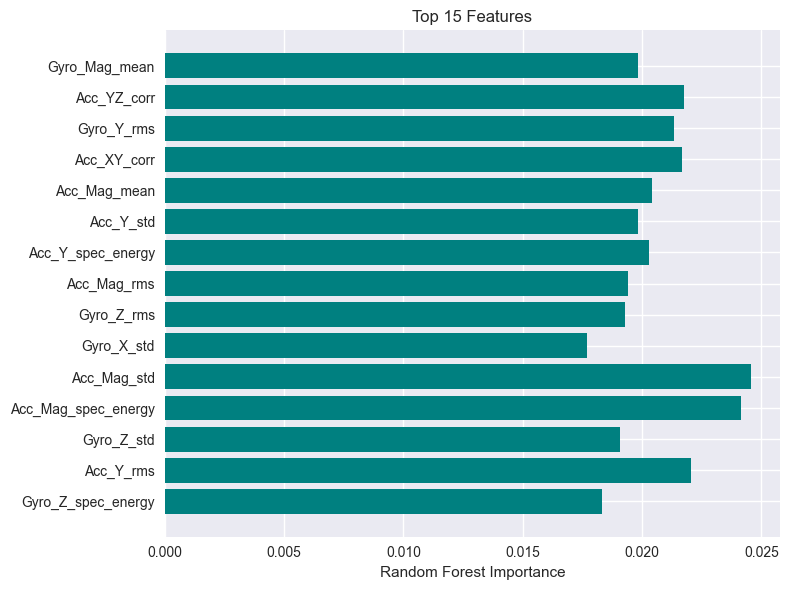

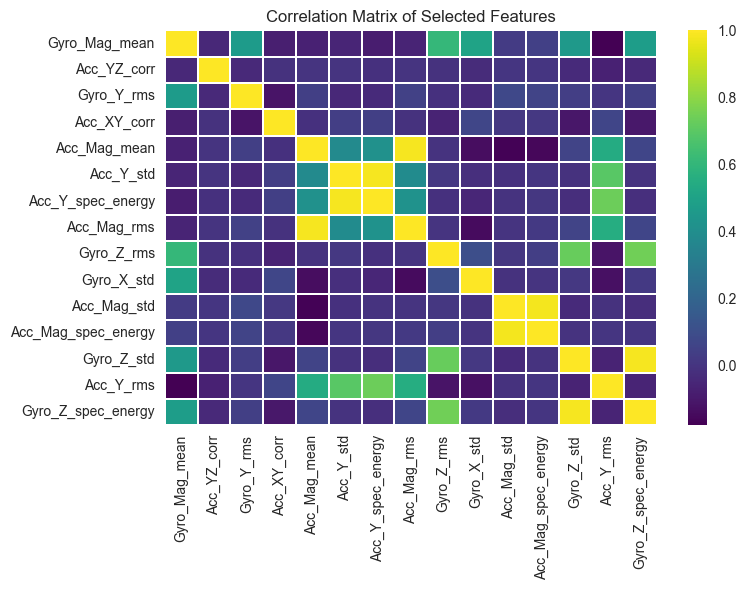

In [258]:

corr_df = feature_df[top_features].corr()
corr_path = FEATURE_OUT_DIR / f"feature_correlation_{FEATURE_FILE_TAG}.csv"
corr_df.to_csv(corr_path)
print(f"Saved correlation matrix -> {corr_path}")

plt.figure(figsize=(8, 6))
top = ranking_df.head(TOP_K).iloc[::-1]
plt.barh(top["feature"], top["rf_importance"], color="teal")
plt.xlabel("Random Forest Importance")
plt.title(f"Top {TOP_K} Features")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"feature_importance_bar_{FEATURE_FILE_TAG}.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, cmap="viridis", linewidths=0.2)
plt.title("Correlation Matrix of Selected Features")
plt.tight_layout()
plt.savefig(PLOT_DIR / f"feature_correlation_heatmap_{FEATURE_FILE_TAG}.png", dpi=300, bbox_inches="tight")
plt.show()


## Outputs
- `out/segmented_windows.csv` and purity-filtered variants - segmented window summaries.
- `out/feature_engineering/engineered_features_all_*.csv` - extracted features before optional purity filtering.
- `out/feature_engineering/engineered_features_model_*.csv` - modeling feature table after configured filters.
- `out/feature_engineering/feature_ranking_*.csv` - ranking metrics computed from train-athlete windows.
- `out/feature_engineering/selected_top*_features_*.csv` - selected feature set for modeling.
- `out/feature_engineering/feature_correlation_*.csv` plus saved plots - diagnostics for selected features.
